
# 03 — MemoryDecay expected baselines and pre-film excess attention

**Purpose.** Fit the snapshot-specific canonical collective-memory decay (MemoryDecay)
baselines, construct expected and excess attention, re-express the matched and strict temporal
comparisons on the excess-attention scale, translate contrasts into decay-equivalent years,
and report the primary Monte Carlo-integrated inference for songs with lower pre-film excess attention.

**Inputs.** `outputs/data/spotify_song_snapshot_panel.csv`, `outputs/data/master_song_panel.csv`,
`results/song_matching_pairs.csv` (notebook 02), and the stored replication-level inference
files under `data/inference/`.

**Outputs (result objects).** `outputs/data/spotify_song_snapshot_excess_attention.csv`,
`results/memorydecay_support.csv`, `results/memorydecay_fits.csv`, `results/memorydecay_model_comparison.csv`,
`results/memorydecay_age_means.csv`, `results/excess_premiums.csv`, `results/matched_excess.csv`,
`results/strict_temporal_{pairs,effects,pooled,balance}.csv`, `results/temporal_excess.csv`,
`results/decay_equivalent_audit.csv`, `results/dormant_definition_support.csv`,
`results/dormant_reduced_form_placebo.csv`, `results/dormant_integrated_inference.csv`,
the SI figures `figure_si_memorydecay_model_comparison.pdf`, `figure_si_dormant_rtm.pdf`, and\n`figure_si_dormant_pseudoevent.pdf`, and the visualization-facing result objects\n`results/decay_equivalent_age_grid.csv` and `results/dormant_assignment_distribution.csv`.

**Unit of analysis.** Song-snapshot observations with valid nonnegative song age (83,780).


In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw_checksums.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display

from cdr import paths, build, util
from cdr.util import SNAPSHOTS, SNAPSHOT_LABEL, check, show_and_save_table, show_and_save_figure

paths.ensure_output_dirs()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
RESULTS = paths.RESULTS

Matplotlib is building the font cache; this may take a moment.


In [2]:
from cdr import memorydecay as md
from cdr import dormant as dm
from cdr import temporal as tmp

panel = pd.read_csv(paths.OUT_DATA / "spotify_song_snapshot_panel.csv", low_memory=False)
panel = panel[panel["age"] >= 0].copy()
master = pd.read_csv(paths.OUT_DATA / "master_song_panel.csv", low_memory=False)
print(f"Expected-attention support: {len(panel):,} song-snapshot observations with nonnegative age")


Expected-attention support: 83,780 song-snapshot observations with nonnegative age



## The expected-attention baseline

The baseline is fitted **only on never-film observations**, separately within each
high-coverage snapshot:

1. **Never-film baseline support**: Billboard records with no observed film appearance.
2. **Integer-age aggregation**: songs are grouped by integer age (floor of years since chart
   debut) and mean Spotify popularity is computed per age cell.
3. **Canonical MemoryDecay function**:
   $S(t) = \frac{N\,[(p-q)e^{-(p+r)t} + r e^{-qt}]}{p+r-q}$, with age $t$ in years.
4. **Log-response objective**: the fit minimizes discrepancies between $\log(\text{observed})$
   and $\log S(t)$; Spotify popularity (a compressed 0–100 index) is *not* pre-logged.
5. **Early-age weighting**: weights $1/(t+10^{-3})$, capped at their 99th percentile, because
   the curve changes fastest near release.
6. **Parameter constraints**: positivity of $N, p, r$ and $0 < q < p+r$ are enforced through a
   log/logit reparametrization.
7. **Multi-start strategy**: every fit is restarted from the full MemoryDecay grid of
   $(p, r, q)$ starts crossed with a data-adaptive grid of $N$ starts; the best converged
   solution by weighted log-space SSE is kept.
8. **Snapshot-specific fitting**: no parameters are shared across the four snapshots.

Each curve summarizes the cross-sectional age-attention relationship within one snapshot.
It does not estimate the longitudinal decay path of an individual song.


In [3]:
support_rows, age_means_frames = [], []
for snap in [s[0] for s in SNAPSHOTS]:
    never = panel[(panel["snapshot"] == snap) & (panel["film_linked"] == 0)]
    agg = md.aggregate_age_means(never)
    agg["snapshot"] = snap
    age_means_frames.append(agg)
    support_rows.append({
        "snapshot": SNAPSHOT_LABEL[snap],
        "never_film_song_snapshots": len(never),
        "positive_age_cells": len(agg),
        "min_age_cell": int(agg["age_int"].min()),
        "max_age_cell": int(agg["age_int"].max()),
        "median_cell_support": float(agg["n"].median()),
        "min_cell_support": int(agg["n"].min()),
    })
support = pd.DataFrame(support_rows)
age_means = pd.concat(age_means_frames, ignore_index=True)
age_means.to_csv(RESULTS / "memorydecay_age_means.csv", index=False)
show_and_save_table(support, RESULTS / "memorydecay_support.csv")


,snapshot,never_film_song_snapshots,positive_age_cells,min_age_cell,max_age_cell,median_cell_support,min_cell_support
0,October 2016,13522,59,0,58,220.0,116
1,July 2017,14056,60,0,59,215.0,139
2,August 2022,17732,65,0,64,249.0,111
3,August 2025,21528,68,0,67,278.0,167


,snapshot,never_film_song_snapshots,positive_age_cells,min_age_cell,max_age_cell,median_cell_support,min_cell_support
0,October 2016,13522,59,0,58,220.0,116
1,July 2017,14056,60,0,59,215.0,139
2,August 2022,17732,65,0,64,249.0,111
3,August 2025,21528,68,0,67,278.0,167


### Snapshot-specific fits and model comparison

The canonical biexponential is compared against exponential and log-normal alternatives fitted
on the same never-film age means with the same early-age weights (the log-normal comparison is
the only model that uses log(age)). In the two older snapshots the canonical fit has a clear
biexponential shape; in the two more recent snapshots the fitted curve has
near-coincident decay rates (flagged below), which the decay-equivalent diagnostics account for.


In [4]:
fits, fit_rows, comp_rows = {}, [], []
for snap in [s[0] for s in SNAPSHOTS]:
    agg = age_means[age_means["snapshot"].eq(snap)]
    fit = md.fit_canonical_gridsearch(agg)
    fits[snap] = fit
    fit_rows.append({"snapshot": SNAPSHOT_LABEL[snap], **{k: fit[k] for k in ["N", "p", "r", "q", "n_age_cells", "n_starts", "rmse_log", "rmse_linear", "single_exponential_limit_flag"]}})
    for f in [fit, md.fit_exponential_log(agg), md.fit_lognormal_log(agg)]:
        comp_rows.append({"snapshot": SNAPSHOT_LABEL[snap], "model": f["model"], "rmse_log": f["rmse_log"], "rmse_linear": f["rmse_linear"], "n_age_cells": f["n_age_cells"]})
fits_table = pd.DataFrame(fit_rows)
comparison = pd.DataFrame(comp_rows)
show_and_save_table(fits_table.round(5), RESULTS / "memorydecay_fits.csv")
show_and_save_table(comparison.round(4), RESULTS / "memorydecay_model_comparison.csv")

check(abs(fits["2016-10"]["N"] - 85.2005) < 0.01 and abs(fits["2016-10"]["p"] - 0.27434) < 0.001, "October 2016 canonical fit reproduces (N=85.20, p=0.274)")
check(abs(fits["2017-07"]["N"] - 84.8765) < 0.01, "July 2017 canonical fit reproduces (N=84.88)")
check(abs(fits["2022-08"]["N"] - 66.3847) < 0.01, "August 2022 canonical fit reproduces (N=66.38)")
check(abs(fits["2025"]["N"] - 69.4002) < 0.01, "August 2025 canonical fit reproduces (N=69.40)")
best = comparison.loc[comparison.groupby("snapshot")["rmse_log"].idxmin()]
check(best["model"].eq("canonical_biexponential_log").all(), "canonical model has the lowest log-space RMSE in every snapshot")


,snapshot,N,p,r,q,n_age_cells,n_starts,rmse_log,rmse_linear,single_exponential_limit_flag
0,October 2016,85.20049,0.27434,0.53539,0.02489,59,195,0.05150,1.36080,False
1,July 2017,84.87649,0.21229,0.52319,0.02349,60,195,0.06592,1.80432,False
2,August 2022,66.38467,0.01362,0.01853,0.03212,65,195,0.05933,2.07403,True
3,August 2025,69.40021,0.01193,0.02212,0.03402,68,195,0.08676,2.76239,True


,snapshot,model,rmse_log,rmse_linear,n_age_cells
0,October 2016,canonical_biexponential_log,0.0515,1.3608,59
1,October 2016,exponential_log,0.0664,2.4090,59
2,October 2016,lognormal_log,0.1259,3.0779,59
3,July 2017,canonical_biexponential_log,0.0659,1.8043,60
4,July 2017,exponential_log,0.0731,2.8993,60
5,July 2017,lognormal_log,0.1517,3.8237,60
6,August 2022,canonical_biexponential_log,0.0593,2.0740,65
7,August 2022,exponential_log,0.0770,2.3405,65
8,August 2022,lognormal_log,0.1441,4.0743,65
9,August 2025,canonical_biexponential_log,0.0868,2.7624,68


PASS: October 2016 canonical fit reproduces (N=85.20, p=0.274)
PASS: July 2017 canonical fit reproduces (N=84.88)
PASS: August 2022 canonical fit reproduces (N=66.38)
PASS: August 2025 canonical fit reproduces (N=69.40)
PASS: canonical model has the lowest log-space RMSE in every snapshot


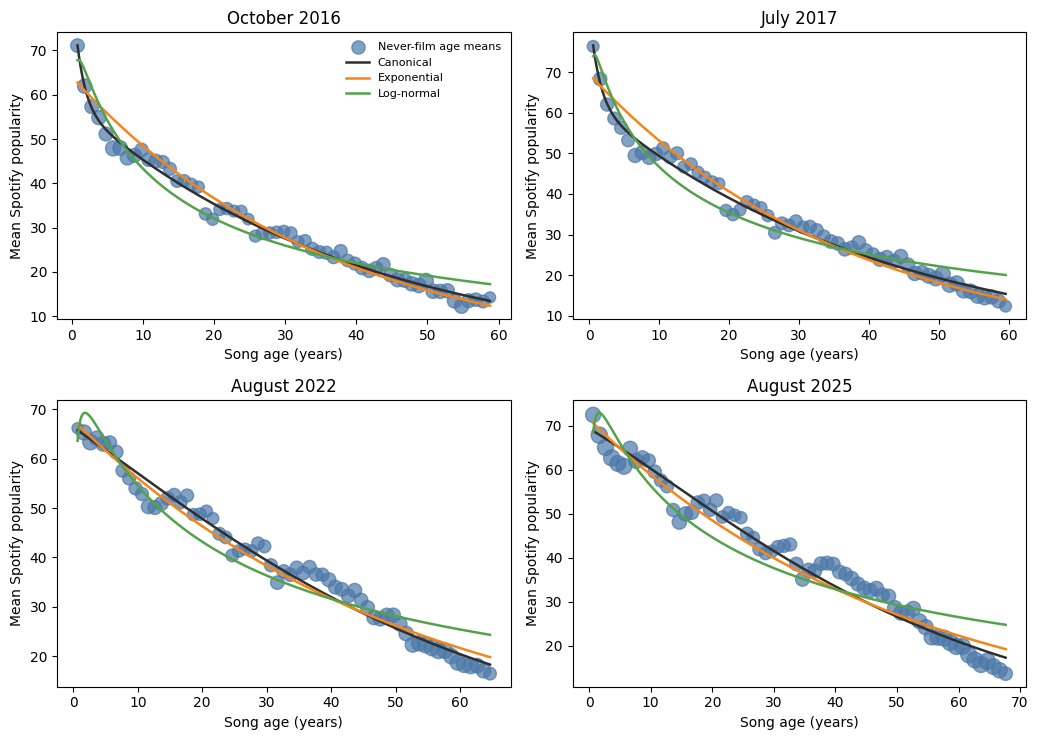

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.5))
colors = {"canonical_biexponential_log": "#2F2F2F", "exponential_log": "#F58518", "lognormal_log": "#54A24B"}
for ax, snap in zip(axes.ravel(), [s[0] for s in SNAPSHOTS]):
    agg = age_means[age_means["snapshot"].eq(snap)]
    ax.scatter(agg["age"], agg["attention"], s=np.sqrt(agg["n"]) * 6, color="#4C78A8", alpha=0.7, label="Never-film age means")
    xs = np.linspace(max(0.05, agg["age"].min()), agg["age"].max(), 300)
    for f, label in [(fits[snap], "Canonical"), (md.fit_exponential_log(agg), "Exponential"), (md.fit_lognormal_log(agg), "Log-normal")]:
        ax.plot(xs, md.predict_comparison_model(f, xs), lw=1.8, color=colors[f["model"]], label=label)
    ax.set_title(SNAPSHOT_LABEL[snap])
    ax.set_xlabel("Song age (years)")
    ax.set_ylabel("Mean Spotify popularity")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
show_and_save_figure(fig, paths.OUT_FIG_SI / "figure_si_memorydecay_model_comparison.pdf")


## Excess-attention levels and temporal changes

Excess attention is observed Spotify popularity minus the fitted snapshot-specific expected
value at the song's age. The broad pooled contrast (`excess ~ film_linked + C(snapshot)`, HC1)
is a difference in attention levels that can reflect prior selection, persistence and later
increases. The time-respecting film-embedded contrast includes only films released by each
snapshot year and is not matched on prior attention. A positive excess-attention level alone
does not establish renewed attention. The temporal comparisons below assess differences in
pre-to-post change relative to matched controls.


In [6]:
panel = md.apply_expected_excess(panel, fits)
panel.to_csv(paths.OUT_DATA / "spotify_song_snapshot_excess_attention.csv", index=False)

rows = []
mod = smf.ols("excess_attention ~ film_linked + C(snapshot)", data=panel).fit(cov_type="HC1")
rows.append(util.model_row(mod, "film_linked", "Pooled film-linked excess premium", len(panel), {"snapshot": "pooled", "layer": "broad attention-regime difference"}))
for snap, _, _, label in SNAPSHOTS:
    d = panel[panel["snapshot"].eq(snap)]
    m = smf.ols("excess_attention ~ film_linked", data=d).fit(cov_type="HC1")
    rows.append(util.model_row(m, "film_linked", label, len(d), {"snapshot": snap, "layer": "snapshot attention-regime difference"}))

exposures = pd.read_csv(paths.OUT_DATA / "snapshot_time_respecting_exposures.csv")
panel_tr = build.merge_time_respecting(panel, exposures)
memb = smf.ols("excess_attention ~ film_linked_by_snapshot + C(snapshot)", data=panel_tr).fit(cov_type="HC1")
rows.append(util.model_row(memb, "film_linked_by_snapshot", "Film-embedded by snapshot (time-respecting)", len(panel_tr), {"snapshot": "pooled", "layer": "time-respecting regime-level displacement"}))
excess_premiums = pd.DataFrame(rows)
show_and_save_table(excess_premiums.round(4), RESULTS / "excess_premiums.csv")
check(abs(excess_premiums.loc[excess_premiums["snapshot"].eq("pooled") & excess_premiums["layer"].str.startswith("broad"), "estimate"].iloc[0] - 19.12) < 0.01, "pooled film-linked excess premium = 19.12")
check(abs(excess_premiums.loc[excess_premiums["comparison"].str.startswith("Film-embedded"), "estimate"].iloc[0] - 19.146) < 0.01, "time-respecting film-embedded regime displacement = 19.15")


,comparison,estimate,std_error,conf_low,conf_high,p_value,n,snapshot,layer
0,Pooled film-linked excess premium,19.1199,0.1325,18.8601,19.3796,0.0,83780,pooled,broad attention-regime difference
1,October 2016,16.4300,0.2569,15.9265,16.9335,0.0,17346,2016-10,snapshot attention-regime difference
2,July 2017,18.1943,0.2614,17.6820,18.7067,0.0,18188,2017-07,snapshot attention-regime difference
3,August 2022,19.8923,0.2691,19.3649,20.4197,0.0,22102,2022-08,snapshot attention-regime difference
4,August 2025,21.2946,0.2626,20.7799,21.8092,0.0,26144,2025,snapshot attention-regime difference
5,Film-embedded by snapshot (time-respecting),19.1463,0.1343,18.8831,19.4095,0.0,83780,pooled,time-respecting regime-level displacement


PASS: pooled film-linked excess premium = 19.12
PASS: time-respecting film-embedded regime displacement = 19.15


### Prior-attention matched comparison on the excess scale

The matched pairs from notebook 02 (prior-attention designs: July 2017, August 2022, and
August 2025, five-point prior-popularity caliper) are re-expressed as excess-attention
differences by joining each pair to the excess panel on the exact song/artist/snapshot record
identity, so every matched pair with defined excess attention (nonnegative song age on both
sides) contributes.


In [7]:
pairs = pd.read_csv(RESULTS / "song_matching_pairs.csv", low_memory=False)
lookup = panel.drop_duplicates(["song", "artist", "snapshot"]).set_index(["song", "artist", "snapshot"])
for side in ["treated", "control"]:
    keys = list(zip(pairs[f"{side}_song"], pairs[f"{side}_artist"], pairs["snapshot"]))
    pairs[f"{side}_excess"] = list(lookup["excess_attention"].reindex(keys))
    if side == "treated":
        pairs["treated_age"] = list(lookup["age"].reindex(keys))
pairs["excess_diff"] = pairs["treated_excess"] - pairs["control_excess"]

matched_rows = []
for (design, snap), g in pairs.dropna(subset=["excess_diff"]).groupby(["design", "snapshot"]):
    est, se, lo, hi, p = util.ci_mean(g["excess_diff"])
    matched_rows.append({"design": design, "snapshot": snap, "n_matched_pairs": len(g), "estimate": est, "std_error": se, "conf_low": lo, "conf_high": hi, "p_value": p, "mean_treated_age": g["treated_age"].mean()})
bl = pairs[pairs["design"].str.startswith("baseline-attention")].dropna(subset=["excess_diff"])
est, se, lo, hi, p = util.ci_mean(bl["excess_diff"])
matched_rows.append({"design": "baseline-attention + historical + artist-success NN", "snapshot": "pooled baseline-attention snapshots", "n_matched_pairs": len(bl), "estimate": est, "std_error": se, "conf_low": lo, "conf_high": hi, "p_value": p, "mean_treated_age": bl["treated_age"].mean()})
matched_excess = pd.DataFrame(matched_rows)
show_and_save_table(matched_excess.round(4), RESULTS / "matched_excess.csv")
MATCHED_EXCESS_EST, MATCHED_EXCESS_CI = est, (lo, hi)
print(f"Baseline-attention matched excess premium: {est:.3f} [{lo:.2f}, {hi:.2f}] over {len(bl):,} matched pairs")
check(len(bl) == 12095, "matched excess comparison uses the full 12,095-pair matched support (excess is undefined for the two pairs with a pre-debut observation)")
check(abs(est - 2.5222) < 0.005, "baseline-attention matched excess premium = 2.52")
check(abs(lo - 2.35) < 0.01 and abs(hi - 2.69) < 0.01, "matched excess 95% CI = [2.35, 2.69]")


,design,snapshot,n_matched_pairs,estimate,std_error,conf_low,conf_high,p_value,mean_treated_age
0,baseline-attention + historical + artist-succe...,2017-07,3797,2.5203,0.1370,2.2519,2.7888,0.0,35.9232
1,baseline-attention + historical + artist-succe...,2022-08,3949,2.6509,0.1748,2.3082,2.9935,0.0,40.8698
2,baseline-attention + historical + artist-succe...,2025,4349,2.4069,0.1411,2.1302,2.6835,0.0,43.0448
3,historical + artist-success NN,2016-10,3824,10.2645,0.2571,9.7607,10.7683,0.0,35.1666
4,historical + artist-success NN,2017-07,4132,11.2262,0.2592,10.7180,11.7343,0.0,35.9392
5,historical + artist-success NN,2022-08,4370,11.4176,0.2769,10.8748,11.9604,0.0,40.1031
6,historical + artist-success NN,2025,4616,11.8490,0.2675,11.3247,12.3734,0.0,43.1236
7,baseline-attention + historical + artist-succe...,pooled baseline-attention snapshots,12095,2.5222,0.0876,2.3504,2.6939,0.0,40.0990


Baseline-attention matched excess premium: 2.522 [2.35, 2.69] over 12,095 matched pairs
PASS: matched excess comparison uses the full 12,095-pair matched support (excess is undefined for the two pairs with a pre-debut observation)
PASS: baseline-attention matched excess premium = 2.52
PASS: matched excess 95% CI = [2.35, 2.69]


### Replacement-aware uncertainty for the matched-excess comparison

Matching uses replacement, so control songs are reused across pairs, and the pooled comparison
also repeats Billboard song identities across snapshots on both sides. Holding the 12,095-pair
set, the pair-level excess differences, and the point estimate fixed, four uncertainty methods
are compared on the identical estimand: the naive paired standard error; a bootstrap over
matched pairs; a cluster bootstrap over unique control song records (capturing reuse within
and across snapshots); and a two-way pigeonhole bootstrap that independently resamples treated
song records and control song records and reweights pairs by the product of their cluster draw
counts. The two-way interval is primary because it accounts jointly for the two sources of
dependence; it is not chosen for width in either direction.


In [8]:
rng_inf = np.random.default_rng(20260712)
N_BOOT_INF = 2000
diff = bl["excess_diff"].to_numpy(float)
n_pairs = len(diff)
t_codes = (bl["treated_song"].astype(str) + "||" + bl["treated_artist"].astype(str)).astype("category").cat.codes.to_numpy()
c_codes = (bl["control_song"].astype(str) + "||" + bl["control_artist"].astype(str)).astype("category").cat.codes.to_numpy()
KT, KC = t_codes.max() + 1, c_codes.max() + 1
est = float(diff.mean())
naive_se = float(diff.std(ddof=1) / np.sqrt(n_pairs))

boot_pairs = diff[rng_inf.integers(0, n_pairs, size=(N_BOOT_INF, n_pairs))].mean(axis=1)

def cluster_boot(codes, K):
    gsum = np.bincount(codes, weights=diff, minlength=K)
    gcnt = np.bincount(codes, minlength=K).astype(float)
    draw = rng_inf.integers(0, K, size=(N_BOOT_INF, K))
    return gsum[draw].sum(axis=1) / gcnt[draw].sum(axis=1)

boot_treated = cluster_boot(t_codes, KT)
boot_control = cluster_boot(c_codes, KC)

two_way = np.empty(N_BOOT_INF)
for b in range(N_BOOT_INF):
    w_t = np.bincount(rng_inf.integers(0, KT, size=KT), minlength=KT).astype(float)
    w_c = np.bincount(rng_inf.integers(0, KC, size=KC), minlength=KC).astype(float)
    w = w_t[t_codes] * w_c[c_codes]
    sw = w.sum()
    two_way[b] = (w * diff).sum() / sw if sw > 0 else np.nan

def row(method, draws, se=None, primary="no"):
    if draws is None:
        lo, hi, s = est - 1.96 * se, est + 1.96 * se, se
    else:
        draws = draws[np.isfinite(draws)]
        lo, hi, s = float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5)), float(draws.std(ddof=1))
    return {"method": method, "estimate": est, "se": s, "ci_low": lo, "ci_high": hi,
            "n_pairs": n_pairs, "n_treated_songs": int(KT), "n_control_songs": int(KC),
            "n_bootstrap": (N_BOOT_INF if draws is not None else np.nan), "primary": primary}

matched_excess_inference = pd.DataFrame([
    row("naive paired SE", None, se=naive_se),
    row("bootstrap over matched pairs", boot_pairs),
    row("block bootstrap over treated song records", boot_treated),
    row("cluster bootstrap over reused control song records", boot_control),
    row("two-way pigeonhole bootstrap (treated x control song records)", two_way, primary="yes"),
])
show_and_save_table(matched_excess_inference.round(4), RESULTS / "matched_excess_inference.csv")
reuse = pd.Series(c_codes).value_counts()
print(f"control reuse: {int(KC):,} unique control songs for {n_pairs:,} pairs (median reuse {reuse.median():.0f}, p95 {reuse.quantile(0.95):.0f}, max {int(reuse.max())})")
primary_row = matched_excess_inference[matched_excess_inference["primary"].eq("yes")].iloc[0]
check(abs(est - 2.5222) < 0.005, "matched-excess point estimate unchanged (2.52) on the identical 12,095-pair set")
check(primary_row["ci_high"] - primary_row["ci_low"] >= 2 * 1.96 * naive_se - 1e-6, "primary two-way interval is at least as wide as the naive paired interval")
check(primary_row["ci_low"] > 0, "matched-excess premium remains positive under replacement-aware two-way inference")
print(f"PRIMARY two-way 95% CI: [{primary_row['ci_low']:.3f}, {primary_row['ci_high']:.3f}] | naive: [{est - 1.96 * naive_se:.3f}, {est + 1.96 * naive_se:.3f}]")


,method,estimate,se,ci_low,ci_high,n_pairs,n_treated_songs,n_control_songs,n_bootstrap,primary
0,naive paired SE,2.5222,0.0876,2.3504,2.6939,12095,4534,4764,NaN,no
1,bootstrap over matched pairs,2.5222,0.0875,2.3458,2.6900,12095,4534,4764,2000.0,no
2,block bootstrap over treated song records,2.5222,0.0886,2.3444,2.6894,12095,4534,4764,2000.0,no
3,cluster bootstrap over reused control song rec...,2.5222,0.1284,2.2692,2.7799,12095,4534,4764,2000.0,no
4,two-way pigeonhole bootstrap (treated x contro...,2.5222,0.1811,2.1586,2.8677,12095,4534,4764,2000.0,yes


control reuse: 4,764 unique control songs for 12,095 pairs (median reuse 2, p95 8, max 38)
PASS: matched-excess point estimate unchanged (2.52) on the identical 12,095-pair set
PASS: primary two-way interval is at least as wide as the naive paired interval
PASS: matched-excess premium remains positive under replacement-aware two-way inference
PRIMARY two-way 95% CI: [2.159, 2.868] | naive: [2.350, 2.694]


## Strict exact-pre-attention matched temporal comparison

Treated songs first observed in a film in 2017 (or 2022) are matched 1:1 without replacement
(optimal assignment) to never-film songs with **identical baseline Spotify attention** (hard
caliper of zero points on the pre-event snapshot) and similar chart history; both sides
require observed snapshots at baseline, event, and post periods. The 2017 cohort uses October
2016 as baseline; the 2022 cohort uses July 2017. Inference uses paired t-tests and sign-flip
randomization inference (5,000 draws, seed 20260602). The evaluated caliper grid
(0, 1, 2, 3, 5 points) yields the same matched support, so only the exact-baseline
specification is reported.


In [9]:
strict = tmp.run_strict_temporal_design(master, seed=20260602)
strict["pairs"].to_csv(RESULTS / "strict_temporal_pairs.csv", index=False)
strict["cohort_effects"].to_csv(RESULTS / "strict_temporal_effects.csv", index=False)
strict["balance"].to_csv(RESULTS / "strict_temporal_balance.csv", index=False)
show_and_save_table(strict["pooled"].round(4), RESULTS / "strict_temporal_pooled.csv")

pooled0 = strict["pooled"][strict["pooled"]["caliper"].eq(0)].set_index("contrast")
bal0 = strict["balance"][strict["balance"]["caliper"].eq(0)]
display(bal0.round(3))
check(int(pooled0.loc["event", "n_pairs"]) == 93, "strict temporal design preserves 93 exact-baseline matched pairs")
check(abs(pooled0.loc["event", "estimate"] - 2.43) < 0.01, "strict temporal event contrast = 2.43 Spotify points")
check(abs(pooled0.loc["post", "estimate"] - 2.94) < 0.01, "strict temporal post contrast = 2.94 Spotify points")
check(pooled0.loc["event", "randomization_p"] < 0.02 and pooled0.loc["post", "randomization_p"] < 0.005, "randomization-inference p-values reproduce (0.010, 0.0012)")
n_by_caliper = strict["balance"].groupby("caliper")["matched_pairs"].sum()
check(n_by_caliper.nunique() == 1, "exact baseline-attention matching yields the same matched support across all evaluated nonnegative calipers")


,caliper,contrast,estimate,std_error,n_pairs,p_value,randomization_p
0,0,event,2.4301,0.9359,93,0.0110,0.0102
1,0,post,2.9355,0.9186,93,0.0019,0.0012
2,1,event,2.4301,0.9359,93,0.0110,0.0088
3,1,post,2.9355,0.9186,93,0.0019,0.0022
4,2,event,2.4301,0.9359,93,0.0110,0.0080
5,2,post,2.9355,0.9186,93,0.0019,0.0022
6,3,event,2.4301,0.9359,93,0.0110,0.0098
7,3,post,2.9355,0.9186,93,0.0019,0.0016
8,5,event,2.4301,0.9359,93,0.0110,0.0098
9,5,post,2.9355,0.9186,93,0.0019,0.0012


,cohort,caliper,matched_pairs,mean_abs_baseline_diff,max_abs_baseline_diff,baseline_smd,chart_year_smd,weeks_smd,peak_smd
0,2017,0,60,0.0,0.0,0.0,-0.055,0.012,-0.036
5,2022,0,33,0.0,0.0,0.0,-0.099,0.048,-0.034


PASS: strict temporal design preserves 93 exact-baseline matched pairs
PASS: strict temporal event contrast = 2.43 Spotify points
PASS: strict temporal post contrast = 2.94 Spotify points
PASS: randomization-inference p-values reproduce (0.010, 0.0012)
PASS: exact baseline-attention matching yields the same matched support across all evaluated nonnegative calipers


### The same 93 pairs on the excess-attention scale

The snapshot-specific MemoryDecay curves are applied directly to the matched-pair Spotify
values (difference-in-change of excess attention between baseline and the event / first-post
snapshot).


In [10]:
p0 = strict["pairs"][strict["pairs"]["caliper"].eq(0)].copy()
pop_col = {"2016-10": "pop2016", "2017-07": "pop2017", "2022-08": "pop2022", "2025": "pop2025"}
tp_rows = []
for _, r in p0.iterrows():
    cohort = int(r["cohort"])
    base, event, post = ("2016-10", "2017-07", "2022-08") if cohort == 2017 else ("2017-07", "2022-08", "2025")
    vals, ok = {}, True
    for pref, cy in [("t", "chart_year_treated"), ("c", "chart_year_control")]:
        cyv = float(r[cy])
        for snap in [base, event, post]:
            age = util.SNAPSHOT_YEAR[snap] - cyv
            expv = md.canonical_curve(np.asarray([age]), fits[snap]["N"], fits[snap]["p"], fits[snap]["r"], fits[snap]["q"])[0]
            if not np.isfinite(expv):
                ok = False
                break
            vals[f"{pref}_{snap}"] = float(r[f"{pref}_{pop_col[snap]}"]) - expv
        if not ok:
            break
    if not ok:
        continue
    tp_rows.append({
        "cohort": cohort,
        "event_diff": (vals[f"t_{event}"] - vals[f"t_{base}"]) - (vals[f"c_{event}"] - vals[f"c_{base}"]),
        "post_diff": (vals[f"t_{post}"] - vals[f"t_{base}"]) - (vals[f"c_{post}"] - vals[f"c_{base}"]),
        "treated_baseline_age": util.SNAPSHOT_YEAR[base] - float(r["chart_year_treated"]),
        "baseline_snapshot": base,
    })
temporal_pairs_excess = pd.DataFrame(tp_rows)
te_rows = []
for contrast, col in [("event", "event_diff"), ("post", "post_diff")]:
    e, se, lo, hi, p = util.ci_mean(temporal_pairs_excess[col])
    te_rows.append({"contrast": contrast, "estimate": e, "std_error": se, "conf_low": lo, "conf_high": hi, "p_value": p, "n_pairs": len(temporal_pairs_excess)})
temporal_excess = pd.DataFrame(te_rows)
temporal_pairs_excess.to_csv(RESULTS / "temporal_excess_pairs.csv", index=False)
show_and_save_table(temporal_excess.round(4), RESULTS / "temporal_excess.csv")
check(abs(temporal_excess.loc[temporal_excess["contrast"].eq("event"), "estimate"].iloc[0] - 2.45) < 0.01, "strict temporal event contrast = 2.45 excess-attention points")
check(abs(temporal_excess.loc[temporal_excess["contrast"].eq("post"), "estimate"].iloc[0] - 2.98) < 0.01, "strict temporal post contrast = 2.98 excess-attention points")


,contrast,estimate,std_error,conf_low,conf_high,p_value,n_pairs
0,event,2.4512,0.9333,0.6219,4.2805,0.0101,93
1,post,2.9849,0.9259,1.1701,4.7998,0.0018,93


PASS: strict temporal event contrast = 2.45 excess-attention points
PASS: strict temporal post contrast = 2.98 excess-attention points


## Decay-equivalent translations

For a contrast $\Delta$ and a song of age $t$, the translation solves
$S(t^*) = S(t) + \Delta$ for $t^* < t$ on the fitted snapshot curve and reports $t - t^*$:
how many years younger the song would need to be to reach the shifted attention level. These
are interpretive translations of observational contrasts, not literal memory recovered. Cases
where the shifted target exceeds the fitted young-age maximum are reported as non-estimable.
The lower-tercile excess-attention translation comes from the integrated nested-bootstrap inference below.


In [11]:
audit_rows = []
def decay_audit_row(label, delta, ages, snaps, distribution, n_pairs):
    vals = md.years_equivalent_distribution(fits, ages, snaps, delta)
    finite = vals[np.isfinite(vals)]
    return {
        "evidence_layer": label, "delta_excess_points": delta,
        "age_distribution": distribution, "n_observations": int(len(vals)),
        "median_years": float(np.nanmedian(vals)),
        "iqr_low": float(np.nanquantile(vals, 0.25)), "iqr_high": float(np.nanquantile(vals, 0.75)),
        "share_nonestimable": float(np.mean(~np.isfinite(vals))),
    }

audit_rows.append(decay_audit_row(
    "Baseline-attention matched excess premium", MATCHED_EXCESS_EST,
    bl["treated_age"], bl["snapshot"], "ages of baseline-attention matched treated songs", len(bl)))
for contrast, col in [("Strict temporal event contrast", "event_diff"), ("Strict temporal post contrast", "post_diff")]:
    delta = float(temporal_pairs_excess[col].mean())
    audit_rows.append(decay_audit_row(
        contrast, delta, temporal_pairs_excess["treated_baseline_age"], temporal_pairs_excess["baseline_snapshot"],
        "baseline ages of the 93 strict temporal matched treated songs", len(temporal_pairs_excess)))
decay_audit = pd.DataFrame(audit_rows)
show_and_save_table(decay_audit.round(4), RESULTS / "decay_equivalent_audit.csv")
MATCHED_DECAY_MEDIAN = float(decay_audit.iloc[0]["median_years"])
check(abs(MATCHED_DECAY_MEDIAN - 3.779) < 0.01, "matched-premium decay-equivalent median = 3.78 years")
check(abs(decay_audit.loc[decay_audit["evidence_layer"].str.startswith("Strict temporal event"), "median_years"].iloc[0] - 3.41) < 0.02, "event decay-equivalent median = 3.41 years")
check(abs(decay_audit.loc[decay_audit["evidence_layer"].str.startswith("Strict temporal post"), "median_years"].iloc[0] - 4.11) < 0.02, "post decay-equivalent median = 4.11 years")


,evidence_layer,delta_excess_points,age_distribution,n_observations,median_years,iqr_low,iqr_high,share_nonestimable
0,Baseline-attention matched excess premium,2.5222,ages of baseline-attention matched treated songs,12095,3.7793,3.0056,4.6400,0.0002
1,Strict temporal event contrast,2.4512,baseline ages of the 93 strict temporal matche...,93,3.4087,2.2025,4.9362,0.0000
2,Strict temporal post contrast,2.9849,baseline ages of the 93 strict temporal matche...,93,4.1140,2.6637,5.9391,0.0000


PASS: matched-premium decay-equivalent median = 3.78 years
PASS: event decay-equivalent median = 3.41 years
PASS: post decay-equivalent median = 4.11 years


## Lower pre-film excess attention: definition and analytical support

The primary subgroup consists of film-linked songs in the **bottom tercile of pre-film excess attention**. This relative definition does not require low absolute Spotify popularity or negative excess attention.
Eligibility requires an observed Spotify snapshot strictly before the first film year (the
latest such snapshot is the baseline) and at least one snapshot at or after it (the first is
the post observation). Songs are identified by the exact Billboard record identity
(song title string, performer string), so no distinct records are collapsed and every
film-linked record maps to its first film year. Pseudo-event controls are never-film songs
assigned event years drawn from the empirical distribution of treated first-film years and
passed through the identical pre/post rule and pre-film excess-attention threshold; matching uses nearest
neighbors with replacement on baseline excess attention, baseline popularity, baseline age,
chart year, Billboard weeks, peak position, and artist-level historical covariates.

The full stochastic inference (500 pseudo-event assignments; 250 nested-bootstrap replications
that refit the MemoryDecay curves, rebuild excess attention and the lower-tercile subgroup,
reassign pseudo-events, and rematch inside every replication) is stored as replication-level
rows under `data/inference/`. The default run validates those files against the raw-derived
analytical-support fingerprint and recomputes every reported summary from the rows;
`FULL_INFERENCE=1` regenerates them deterministically from seed.


In [12]:
dormant_panel = panel.assign(song_artist_id=panel["song"].astype(str) + "||" + panel["artist"].astype(str))
first_year_map = (
    master.assign(record_id=master["song"].astype(str) + "||" + master["artist"].astype(str))
    .query("film_linked == 1").dropna(subset=["first_year"]).set_index("record_id")["first_year"]
)
wide = dm.build_snapshot_wide(dormant_panel)
base_d = dm.prepare_dormant_base(wide, None, first_year_map)
definition_support = pd.DataFrame([
    {"quantity": "film-linked songs with pre-film and post-film Spotify snapshots", "n": len(base_d["treated"])},
    {"quantity": "bottom-tercile pre-film excess-attention threshold (q33)", "n": round(base_d["q33"], 3)},
    {"quantity": "dormant treated songs (bottom tercile)", "n": len(base_d["treated_dormant"])},
])
show_and_save_table(definition_support, RESULTS / "dormant_definition_support.csv")
check(len(base_d["treated"]) == 355, "355 film-linked songs have pre-film and post-film Spotify support")
check(len(base_d["treated_dormant"]) == 119, "119 dormant treated songs (bottom tercile of pre-film excess attention)")
display(base_d["treated_event_years"].describe().to_frame("treated first-film (event) years"))


,quantity,n
0,film-linked songs with pre-film and post-film ...,355.000
1,bottom-tercile pre-film excess-attention thres...,9.876
2,dormant treated songs (bottom tercile),119.000


PASS: 355 film-linked songs have pre-film and post-film Spotify support
PASS: 119 dormant treated songs (bottom tercile of pre-film excess attention)


,treated first-film (event) years
count,355.000000
mean,2019.236620
std,1.598131
min,2017.000000
25%,2018.000000
50%,2019.000000
75%,2021.000000
max,2022.000000


### Baseline-attention definitions (single-assignment robustness)

Four definitions based on raw baseline popularity and one based on a regression residual are
retained as robustness checks: bottom-quartile and bottom-tercile baseline popularity, the
bottom tercile of the residual from a raw regression of baseline popularity on age, age
squared, weeks, and peak position, historically successful low-attention songs (low-support exploratory definition), and older
low-attention songs. Controls receive one seeded pseudo-event assignment and the same
matching; uncertainty uses a bootstrap over matched treated songs (1,000 draws) and a
label-permutation test (2,000 draws), seed 20260603.


In [13]:
rng = np.random.default_rng(20260603)
pop_cols = {label: col for label, _, col, _ in SNAPSHOTS}
treated_master = master[master["film_linked"].eq(1) & master["first_year"].notna()]
treated_pp = pd.DataFrame([x for x in (dm.raw_prepost_for_event(r, float(r["first_year"]), pop_cols) for _, r in treated_master.iterrows()) if x is not None])
controls_master = master[master["film_linked"].eq(0)]
pseudo_years = rng.choice(treated_pp["event_year"].dropna().to_numpy(), size=len(controls_master), replace=True)
control_pp = pd.DataFrame([x for x in (dm.raw_prepost_for_event(r, float(fy), pop_cols) for (_, r), fy in zip(controls_master.iterrows(), pseudo_years)) if x is not None])
print(f"treated with pre/post support: {len(treated_pp)} | pseudo-event controls with pre/post support: {len(control_pp)}")

treated_cls, thresholds = dm.classify_dormant_reduced(treated_pp)
control_cls = dm.classify_dormant_reduced(control_pp, thresholds)
summaries, balances = [], []
for label, key in dm.REDUCED_FORM_DEFINITIONS:
    td = treated_cls[dm.reduced_dormant_mask(treated_cls, key)].copy()
    cd = control_cls[dm.reduced_dormant_mask(control_cls, key)].copy()
    if len(td) < 5 or len(cd) < 5:
        continue
    out = dm.estimate_reduced_definition(td, cd, label, rng)
    if out is None:
        continue
    s, bal, _ = out
    summaries.append(s)
    balances.append(bal)
reduced = pd.DataFrame(summaries)
show_and_save_table(reduced.round(3), RESULTS / "dormant_reduced_form_placebo.csv")
pd.concat(balances, ignore_index=True).to_csv(RESULTS / "dormant_reduced_form_balance.csv", index=False)
powered = reduced[reduced["n_dormant_treated"] >= 30]
check((powered["placebo_adjusted_did"] > 0).all() and (powered["boot_ci_low"] > 0).all(),
      "all larger-sample reduced-form definitions give positive placebo-adjusted increases with bootstrap CIs excluding zero")
check((powered["max_abs_smd_after"] < 0.1).all(), "reduced-form placebo matching keeps maximum absolute SMD below 0.1")


treated with pre/post support: 356 | pseudo-event controls with pre/post support: 14070


,definition,n_dormant_treated,n_dormant_control,n_matched_pairs,treated_change_mean,matched_control_change_mean,placebo_adjusted_did,boot_ci_low,boot_ci_high,permutation_p_value,did_no_replacement,n_matched_pairs_no_replacement,max_abs_smd_after
0,"Low baseline Spotify attention, bottom quartile",97,8418,97,10.928,3.866,7.062,4.648,9.434,0.000,6.711,97,0.029
1,"Low baseline Spotify attention, bottom tercile",124,9696,124,10.161,4.597,5.565,3.564,7.758,0.000,5.290,124,0.039
2,"Reduced-form below-expected residual, bottom t...",119,10378,119,9.395,5.639,3.756,1.916,5.757,0.000,3.605,119,0.062
3,Historically successful but low baseline atten...,19,886,19,10.842,6.105,4.737,-0.053,9.737,0.737,4.737,19,0.125
4,Older low-attention songs,94,6833,94,10.926,3.202,7.723,5.329,10.224,0.000,7.532,94,0.033


PASS: all larger-sample reduced-form definitions give positive placebo-adjusted increases with bootstrap CIs excluding zero
PASS: reduced-form placebo matching keeps maximum absolute SMD below 0.1


### Baseline-attention groups: descriptive scale (treated songs only)

Raw first-post and maximum-post popularity changes by reduced-form baseline-attention group; a
descriptive ordering, not a randomized estimate.


In [14]:
regime_means = (
    treated_cls.groupby("memory_regime")
    .agg(n_songs=("first_post_change", "size"),
         first_post_change_mean=("first_post_change", "mean"),
         first_post_change_sem=("first_post_change", util.sem),
         max_post_change_mean=("max_post_change", "mean"),
         max_post_change_sem=("max_post_change", util.sem))
    .reset_index()
)
show_and_save_table(regime_means.round(3), RESULTS / "dormant_regime_means.csv")


,memory_regime,n_songs,first_post_change_mean,first_post_change_sem,max_post_change_mean,max_post_change_sem
0,dormant/below-expected,119,9.395,0.854,12.731,0.832
1,intermediate-memory,118,5.619,0.817,8.898,0.801
2,persistent/above-expected,119,2.899,0.659,5.992,0.744


,memory_regime,n_songs,first_post_change_mean,first_post_change_sem,max_post_change_mean,max_post_change_sem
0,dormant/below-expected,119,9.395,0.854,12.731,0.832
1,intermediate-memory,118,5.619,0.817,8.898,0.801
2,persistent/above-expected,119,2.899,0.659,5.992,0.744


### Regression-to-the-mean structure across baseline-attention definitions (SI figure)

The figure contrasts, for each retained baseline-attention definition, the raw treated change with the
matched pseudo-event control change, and shows the placebo-adjusted residual with its
bootstrap interval. Treated and matched-control changes are positive, and a positive film-linked
increment remains across the larger-sample definitions. The regression-residual definition is
relative to its fitted baseline and does not require low absolute popularity.


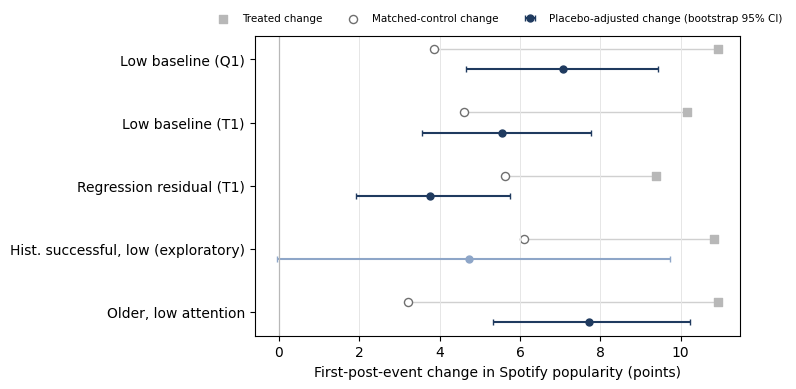

In [15]:
DEF_SHORT = {
    "Low baseline Spotify attention, bottom quartile": "Low baseline (Q1)",
    "Low baseline Spotify attention, bottom tercile": "Low baseline (T1)",
    "Reduced-form below-expected residual, bottom tercile": "Regression residual (T1)",
    "Historically successful but low baseline attention": "Hist. successful, low (exploratory)",
    "Older low-attention songs": "Older, low attention",
}
d = reduced.copy()
d["label"] = d["definition"].map(DEF_SHORT)
d["low_support"] = d["n_dormant_treated"] < 30
d = d.iloc[::-1].reset_index(drop=True)
y = np.arange(len(d))
fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.scatter(d["treated_change_mean"], y + 0.16, marker="s", s=34, color="#B8B8B8", label="Treated change")
ax.scatter(d["matched_control_change_mean"], y + 0.16, marker="o", s=34, facecolors="white", edgecolors="#6F6F6F", label="Matched-control change")
for i, row in d.iterrows():
    ax.plot([row["matched_control_change_mean"], row["treated_change_mean"]], [y[i] + 0.16, y[i] + 0.16], color="#D0D0D0", lw=1, zorder=0)
    color = "#8EA6C8" if row["low_support"] else "#1F3A5F"
    ax.errorbar(row["placebo_adjusted_did"], y[i] - 0.16,
                xerr=[[row["placebo_adjusted_did"] - row["boot_ci_low"]], [row["boot_ci_high"] - row["placebo_adjusted_did"]]],
                fmt="o", color=color, ecolor=color, capsize=2.5, markersize=5,
                label="Placebo-adjusted change (bootstrap 95% CI)" if i == 0 else None)
ax.axvline(0, color="#B8B8B8", lw=0.9)
ax.set_yticks(y)
ax.set_yticklabels(d["label"])
ax.set_xlabel("First-post-event change in Spotify popularity (points)")
ax.legend(frameon=False, fontsize=7.5, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=3)
ax.grid(axis="x", color="#E6E6E6", lw=0.7)
fig.tight_layout()
show_and_save_figure(fig, paths.OUT_FIG_SI / "figure_si_dormant_rtm.pdf")


## Primary integrated inference for lower pre-film excess attention from the stored replication files

The default run validates the raw-derived analytical-support fingerprint and the stored-file
checksums and row counts, then recomputes **every** reported summary from the replication-level
rows (no summary file is used as a primary source).


In [16]:
fingerprint = md.dormant_support_fingerprint(dormant_panel)
metadata = dm.validate_inference_files(fingerprint)
print("Analytical-support fingerprint validated:", fingerprint[:16], "...")
mc = pd.read_csv(paths.INFERENCE / "dormant_pseudoevent_monte_carlo_replications.csv")
boot = pd.read_csv(paths.INFERENCE / "dormant_integrated_bootstrap_replications.csv")
check(len(mc) == 500 and mc["seed"].nunique() == 500, "500 stored pseudo-event assignments with unique deterministic seeds")
check(len(boot) == 250, "250 stored nested-bootstrap replications")
check(int(mc["N_matched_pairs"].iloc[0]) == len(base_d["treated_dormant"]), "stored matched support equals the raw-derived dormant treated support (119 pairs per assignment)")
(paths.OUT_DATA / "dormant_analytical_support_fingerprint.txt").write_text(fingerprint + "\n")

summary = dm.summarize_stored_inference(mc, boot)
dormant_inference = pd.DataFrame([summary])
show_and_save_table(dormant_inference.round(4).T.reset_index().rename(columns={"index": "quantity", 0: "value"}), RESULTS / "dormant_integrated_inference.csv")

check(summary["n_positive_assignments"] == 500, "all 500 pseudo-event assignment contrasts are positive")
check(abs(summary["dormant_excess_point_estimate"] - 5.044) < 0.01, "integrated dormant excess contrast = 5.04")
# Bootstrap-dependent checks use accepted references and the validated replication rows.
bootstrap_reference = pd.read_csv(paths.DATA / "expected_results.csv").set_index("result_id")["expected_value"]
bootstrap_columns = ["dormant_excess_attention", "exit_difference_pp", "median_decay_equivalent_years", "treated_exit_probability", "control_exit_probability"]
check(np.isfinite(boot[bootstrap_columns].to_numpy(float)).all(), "all 250 corrected bootstrap rows have finite headline quantities")
bootstrap_quantiles = boot[bootstrap_columns].quantile([0.025, 0.975])
check(abs(summary["dormant_excess_integrated_ci_low"] - bootstrap_reference["dormant_excess_ci_low"]) < 0.01 and abs(summary["dormant_excess_integrated_ci_high"] - bootstrap_reference["dormant_excess_ci_high"]) < 0.01, "integrated 95% CI reproduces the accepted corrected references")
check(abs(summary["assignment_mean"] - 5.044) < 0.01 and abs(summary["assignment_median"] - 5.029) < 0.01 and abs(summary["assignment_sd"] - 0.436) < 0.01, "assignment mean/median/SD = 5.044 / 5.029 / 0.436")
check(abs(summary["assignment_interval_low"] - 4.243) < 0.01 and abs(summary["assignment_interval_high"] - 5.997) < 0.01, "pseudo-event assignment interval = [4.24, 6.00] (design-stability distribution, not a CI)")
check(abs(summary["treated_exit_probability"] - 0.39496) < 0.001 and abs(summary["control_exit_probability"] - 0.21510) < 0.001, "low-memory exit probabilities = 39.496% vs 21.510%")
check(abs(summary["exit_difference_pp"] - 17.987) < 0.01, "low-memory exit difference = 17.99 pp")
check(abs(summary["exit_integrated_ci_low"] - bootstrap_quantiles.loc[0.025, "exit_difference_pp"]) < 0.05 and abs(summary["exit_integrated_ci_high"] - bootstrap_quantiles.loc[0.975, "exit_difference_pp"]) < 0.05, "above-threshold integrated 95% CI reproduces the corrected replication percentiles")
check(abs(summary["dormant_decay_equivalent_years"] - bootstrap_reference["decay_equivalent_years"]) < 0.01, "decay-equivalent translation reproduces the accepted corrected reference")
check(abs(summary["dormant_decay_integrated_ci_low"] - bootstrap_quantiles.loc[0.025, "median_decay_equivalent_years"]) < 0.02 and abs(summary["dormant_decay_integrated_ci_high"] - bootstrap_quantiles.loc[0.975, "median_decay_equivalent_years"]) < 0.02, "decay-equivalent integrated 95% CI reproduces the corrected replication percentiles")
print(f"Inversion failure rate: {summary['inversion_failure_rate']:.4f} | boundary-hit rate: {summary['boundary_hit_rate']:.4f}")


Analytical-support fingerprint validated: 8cbff8c72d92285b ...
PASS: 500 stored pseudo-event assignments with unique deterministic seeds
PASS: 250 stored nested-bootstrap replications
PASS: stored matched support equals the raw-derived dormant treated support (119 pairs per assignment)


,quantity,value
0,n_pseudo_event_assignments,500.0000
1,n_positive_assignments,500.0000
2,assignment_mean,5.0438
3,assignment_median,5.0285
4,assignment_sd,0.4355
5,assignment_interval_low,4.2427
6,assignment_interval_high,5.9974
7,dormant_excess_point_estimate,5.0438
8,dormant_excess_integrated_ci_low,2.9717
9,dormant_excess_integrated_ci_high,6.8680


PASS: all 500 pseudo-event assignment contrasts are positive
PASS: integrated dormant excess contrast = 5.04
PASS: all 250 corrected bootstrap rows have finite headline quantities
PASS: integrated 95% CI reproduces the accepted corrected references
PASS: assignment mean/median/SD = 5.044 / 5.029 / 0.436
PASS: pseudo-event assignment interval = [4.24, 6.00] (design-stability distribution, not a CI)
PASS: low-memory exit probabilities = 39.496% vs 21.510%
PASS: low-memory exit difference = 17.99 pp
PASS: above-threshold integrated 95% CI reproduces the corrected replication percentiles
PASS: decay-equivalent translation reproduces the accepted corrected reference
PASS: decay-equivalent integrated 95% CI reproduces the corrected replication percentiles
Inversion failure rate: 0.0001 | boundary-hit rate: 0.0001


### Decay-equivalent age grid and assignment-distribution result objects

Two visualization-facing result objects are saved for the curated figures: (i) a long-form
age grid of decay-equivalent translations for the conservative/residual evidence layers,
computed from the same fitted snapshot-specific curves and inversion semantics used above
(a fixed excess-attention displacement maps to different decay-equivalent years depending on
song age and the fitted trajectory); (ii) the 500 assignment-specific lower-tercile excess-attention contrasts.
The age grid is restricted to the common positive-age support of the four fitted baselines
(ages 1 through the smallest maximum observed never-film age cell across snapshots), so no
curve extrapolates beyond the empirical support of its fitted trajectory.


In [17]:
AGE_GRID_LAYERS = [
    ("Matched residual", MATCHED_EXCESS_EST),
    ("Temporal event", float(temporal_excess.set_index("contrast").loc["event", "estimate"])),
    ("Temporal post", float(temporal_excess.set_index("contrast").loc["post", "estimate"])),
    ("Dormant integrated", float(summary["dormant_excess_point_estimate"])),
]
common_max_age = min(int(support.loc[support["snapshot"].eq(SNAPSHOT_LABEL[s]), "max_age_cell"].iloc[0]) for s in [x[0] for x in SNAPSHOTS])
print(f"common empirical age support of the four fitted baselines: 1-{common_max_age}")
grid_rows = []
for layer, delta in AGE_GRID_LAYERS:
    for snap in [s[0] for s in SNAPSHOTS]:
        for age in range(1, common_max_age + 1):
            val, status = md.years_equivalent_one(fits[snap], float(age), delta)
            grid_rows.append({"evidence_layer": layer, "snapshot": SNAPSHOT_LABEL[snap], "song_age": age,
                              "delta_excess": delta, "decay_equivalent_years": val, "inversion_status": status})
age_grid = pd.DataFrame(grid_rows)
show_and_save_table(age_grid, RESULTS / "decay_equivalent_age_grid.csv", max_rows=8)
grid_share = age_grid.groupby("evidence_layer")["decay_equivalent_years"].apply(lambda s: float(s.notna().mean()))
display(grid_share.to_frame("share of age cells with a valid inversion").round(3))
check(age_grid["decay_equivalent_years"].notna().mean() > 0.9, "decay-equivalent inversions are valid over the large majority of the age grid")

assignment_distribution = mc[["replication", "seed", "excess_attention_estimate"]].copy()
assignment_distribution.to_csv(RESULTS / "dormant_assignment_distribution.csv", index=False)
print(f"saved 500 assignment-specific contrasts (min {assignment_distribution['excess_attention_estimate'].min():.3f}, all positive: {(assignment_distribution['excess_attention_estimate'] > 0).all()})")


common empirical age support of the four fitted baselines: 1-58


,evidence_layer,snapshot,song_age,delta_excess,decay_equivalent_years,inversion_status
0,Matched residual,October 2016,1,2.522156,0.209348,valid
1,Matched residual,October 2016,2,2.522156,0.388854,valid
2,Matched residual,October 2016,3,2.522156,0.647759,valid
3,Matched residual,October 2016,4,2.522156,0.960490,valid
4,Matched residual,October 2016,5,2.522156,1.280532,valid
5,Matched residual,October 2016,6,2.522156,1.563616,valid
6,Matched residual,October 2016,7,2.522156,1.785221,valid
7,Matched residual,October 2016,8,2.522156,1.945109,valid


,share of age cells with a valid inversion
evidence_layer,
Dormant integrated,0.957
Matched residual,0.983
Temporal event,0.983
Temporal post,0.974


PASS: decay-equivalent inversions are valid over the large majority of the age grid
saved 500 assignment-specific contrasts (min 3.698, all positive: True)


### Pseudo-event assignment stability

Pseudo-event integration is part of the primary lower-tercile excess-attention design, so the distribution of the 500
assignment-specific contrasts is a retained SI diagnostic. The percentile band below is a
design-stability distribution across assignments, not a confidence interval; sampling
uncertainty is carried by the integrated nested bootstrap.


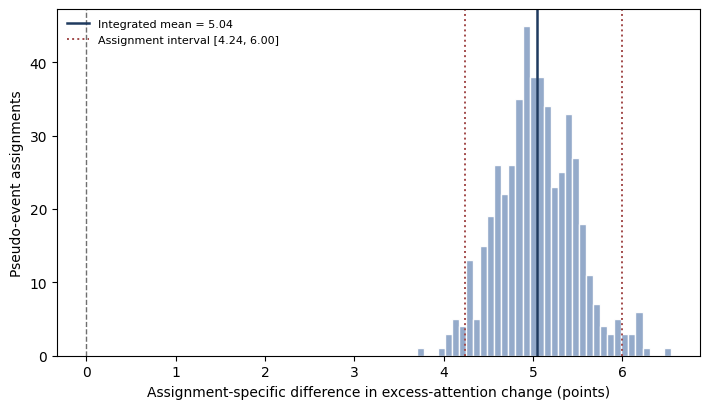

In [18]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
est = mc["excess_attention_estimate"]
ax.hist(est, bins=36, color="#8EA6C8", edgecolor="white", alpha=0.95)
ax.axvline(0, color="#6F6F6F", lw=1.0, ls="--")
ax.axvline(summary["assignment_mean"], color="#1F3A5F", lw=1.8, label=f"Integrated mean = {summary['assignment_mean']:.2f}")
ax.axvline(summary["assignment_interval_low"], color="#A24B4B", lw=1.4, ls=":", label=f"Assignment interval [{summary['assignment_interval_low']:.2f}, {summary['assignment_interval_high']:.2f}]")
ax.axvline(summary["assignment_interval_high"], color="#A24B4B", lw=1.4, ls=":")
ax.set_xlabel("Assignment-specific difference in excess-attention change (points)")
ax.set_ylabel("Pseudo-event assignments")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
show_and_save_figure(fig, paths.OUT_FIG_SI / "figure_si_dormant_pseudoevent.pdf")


### Full stochastic regeneration (`FULL_INFERENCE=1`)

Setting `FULL_INFERENCE=1` reruns the complete procedure — 500 pseudo-event assignments and
250 full nested-bootstrap replications with MemoryDecay refitting, excess-attention
reconstruction, lower-tercile subgroup redefinition, pseudo-event reassignment, and rematching — on the
raw-derived pre/post-event base and regenerates the stored replication files, checksums, and
metadata under `data/inference/` deterministically from the recorded seeds.


In [19]:
import os
if os.environ.get("FULL_INFERENCE") == "1":
    mc_full = dm.monte_carlo_pseudoevent(wide, first_year_map, n_rep=500)
    boot_full = dm.integrated_bootstrap(dormant_panel, wide, first_year_map, fits, n_rep=250)
    dm.write_inference_files(mc_full, boot_full, fingerprint)
    display(pd.DataFrame([dm.summarize_stored_inference(mc_full, boot_full)]).round(4).T)
else:
    print("FULL_INFERENCE not set: using the validated stored replication files (default).")


FULL_INFERENCE not set: using the validated stored replication files (default).


## Paper artifacts for this section

Main Table 2, Figure 2, and the expected-attention, balance, matched-excess, and baseline-attention SI tables are generated here, from the result objects this notebook produces.

In [20]:
# Paper-artifact helpers: shared figure style, LaTeX writers, result-object reader.
from matplotlib.gridspec import GridSpec

from cdr import tex
from cdr.tex import fmt_num, fmt_int, fmt_p, fmt_ci
from cdr.util import (ACCENT, BLUE, CHARCOAL, COV_LABEL, DARK_BLUE, GRAY, GREEN, GRID,
                      LIGHT_BLUE, LIGHT_GRAY, SNAP_SHORT, errorbarh, errorbarv,
                      panel_label, set_plot_style)

set_plot_style()
R = lambda name: pd.read_csv(RESULTS / name, low_memory=False)

In [21]:
excess = R("excess_premiums.csv")
matched = R("matched_excess.csv")
mx_inf = R("matched_excess_inference.csv")
mx_primary = mx_inf[mx_inf["primary"].eq("yes")].iloc[0]
temporal = R("temporal_excess.csv")
decay = R("decay_equivalent_audit.csv")
dorm = R("dormant_integrated_inference.csv").set_index("quantity")["value"]

pooled = excess[excess["comparison"].eq("Pooled film-linked excess premium")].iloc[0]
embedded = excess[excess["comparison"].str.startswith("Film-embedded")].iloc[0]
mrow = matched[matched["snapshot"].str.startswith("pooled")].iloc[0]
ev = temporal.set_index("contrast").loc["event"]
po = temporal.set_index("contrast").loc["post"]
d_matched = decay.set_index("evidence_layer")
rows = [
    ["Pooled film-linked excess premium", f"{pooled['estimate']:.2f} excess-attention points", fmt_ci(pooled["conf_low"], pooled["conf_high"]), "--", "broad excess-attention difference"],
    ["Film-embedded by snapshot (time-respecting)", f"{embedded['estimate']:.2f} excess-attention points", fmt_ci(embedded["conf_low"], embedded["conf_high"]), "--", "time-respecting excess-attention difference"],
    ["Prior-attention matched excess premium", f"{mrow['estimate']:.2f} excess-attention points", fmt_ci(mx_primary["ci_low"], mx_primary["ci_high"]) + " two-way cluster bootstrap", f"{d_matched.loc['Baseline-attention matched excess premium', 'median_years']:.2f}", "matched observational comparison"],
    ["Strict temporal event contrast", f"{ev['estimate']:.2f} excess-attention points", fmt_ci(ev["conf_low"], ev["conf_high"]), f"{d_matched.loc['Strict temporal event contrast', 'median_years']:.2f}", "conservative temporal check"],
    ["Strict temporal post contrast", f"{po['estimate']:.2f} excess-attention points", fmt_ci(po["conf_low"], po["conf_high"]), f"{d_matched.loc['Strict temporal post contrast', 'median_years']:.2f}", "conservative temporal check"],
    ["Lower pre-film excess-attention contrast", f"{dorm['dormant_excess_point_estimate']:.2f} excess-attention points", fmt_ci(dorm["dormant_excess_integrated_ci_low"], dorm["dormant_excess_integrated_ci_high"]) + " integrated bootstrap", f"{dorm['dormant_decay_equivalent_years']:.2f} " + fmt_ci(dorm["dormant_decay_integrated_ci_low"], dorm["dormant_decay_integrated_ci_high"]), "placebo-adjusted difference in change among songs in the lower pre-film excess-attention tercile"],
    ["Exceeding the pre-film threshold", f"{dorm['exit_difference_pp']:.1f} percentage-point difference ({100*dorm['treated_exit_probability']:.1f}\\% vs {100*dorm['control_exit_probability']:.1f}\\%)", fmt_ci(dorm["exit_integrated_ci_low"], dorm["exit_integrated_ci_high"], 1) + " pp integrated bootstrap", "--", "difference in above-threshold probability"],
]
main_t2 = pd.DataFrame(rows, columns=["Result", "Estimate", "95% CI / uncertainty", "Median decay-equivalent years", "Interpretation"])
display(main_t2)
tex.write_table(paths.OUT_TABLES_MAIN / "table_memory_decay_key_results.tex",
    "Excess-attention differences and temporal changes.", "tab:memory-decay-key-results",
    ["Result", "Estimate", r"\makecell[l]{95\% CI /\\ uncertainty}", r"\makecell[b]{Median\\ decay-equivalent\\ years}", "Interpretation"],
    main_t2.values.tolist(),
    note=("Excess attention is observed Spotify popularity minus the fitted age/snapshot-specific expected attention from canonical collective-memory decay curves estimated on never-film age means. "
          "Intervals: HC1 for the broad and film-embedded rows; a two-way cluster bootstrap over treated and reused control song records for the matched residual, accounting for control reuse and repeated song identities; matched-pair standard errors for the strict temporal rows ($n=93$ pairs); integrated nested-bootstrap inference (song-level resampling, decay-curve refitting, pseudo-event reassignment, and rematching) for the lower-tercile excess-attention rows. "
          "Decay-equivalent years ask how many years younger a song would need to be, under the fitted expected-attention curve, to reach the shifted attention level; they are interpretive translations, not literal measures of memory recovered or randomized causal effects."),
    layout="tabularx",
    col_spec=r"@{}>{\raggedright\arraybackslash}p{0.175\linewidth}>{\raggedright\arraybackslash}p{0.15\linewidth}>{\raggedright\arraybackslash}p{0.155\linewidth}>{\centering\arraybackslash}p{0.145\linewidth}>{\raggedright\arraybackslash}X@{}",
    size=r"\small", stretch=1.15, escape_cells=False)

,Result,Estimate,95% CI / uncertainty,Median decay-equivalent years,Interpretation
0,Pooled film-linked excess premium,19.12 excess-attention points,"[18.86, 19.38]",--,broad excess-attention difference
1,Film-embedded by snapshot (time-respecting),19.15 excess-attention points,"[18.88, 19.41]",--,time-respecting excess-attention difference
2,Prior-attention matched excess premium,2.52 excess-attention points,"[2.16, 2.87] two-way cluster bootstrap",3.78,matched observational comparison
3,Strict temporal event contrast,2.45 excess-attention points,"[0.62, 4.28]",3.41,conservative temporal check
4,Strict temporal post contrast,2.98 excess-attention points,"[1.17, 4.80]",4.11,conservative temporal check
5,Lower pre-film excess-attention contrast,5.04 excess-attention points,"[2.97, 6.87] integrated bootstrap","6.88 [3.89, 10.22]",placebo-adjusted difference in change among so...
6,Exceeding the pre-film threshold,18.0 percentage-point difference (39.5\% vs 21...,"[6.7, 27.6] pp integrated bootstrap",--,difference in above-threshold probability


**Excess-attention differences and temporal changes.** (`tab:memory-decay-key-results`)

,Result,Estimate,95% CI / uncertainty,Median decay-equivalent years,Interpretation
0,Pooled film-linked excess premium,19.12 excess-attention points,"[18.86, 19.38]",--,broad excess-attention difference
1,Film-embedded by snapshot (time-respecting),19.15 excess-attention points,"[18.88, 19.41]",--,time-respecting excess-attention difference
2,Prior-attention matched excess premium,2.52 excess-attention points,"[2.16, 2.87] two-way cluster bootstrap",3.78,matched observational comparison
3,Strict temporal event contrast,2.45 excess-attention points,"[0.62, 4.28]",3.41,conservative temporal check
4,Strict temporal post contrast,2.98 excess-attention points,"[1.17, 4.80]",4.11,conservative temporal check
5,Lower pre-film excess-attention contrast,5.04 excess-attention points,"[2.97, 6.87] integrated bootstrap","6.88 [3.89, 10.22]",placebo-adjusted difference in change among so...
6,Exceeding the pre-film threshold,18.0 percentage-point difference (39.5% vs 21.5%),"[6.7, 27.6] pp integrated bootstrap",--,difference in above-threshold probability


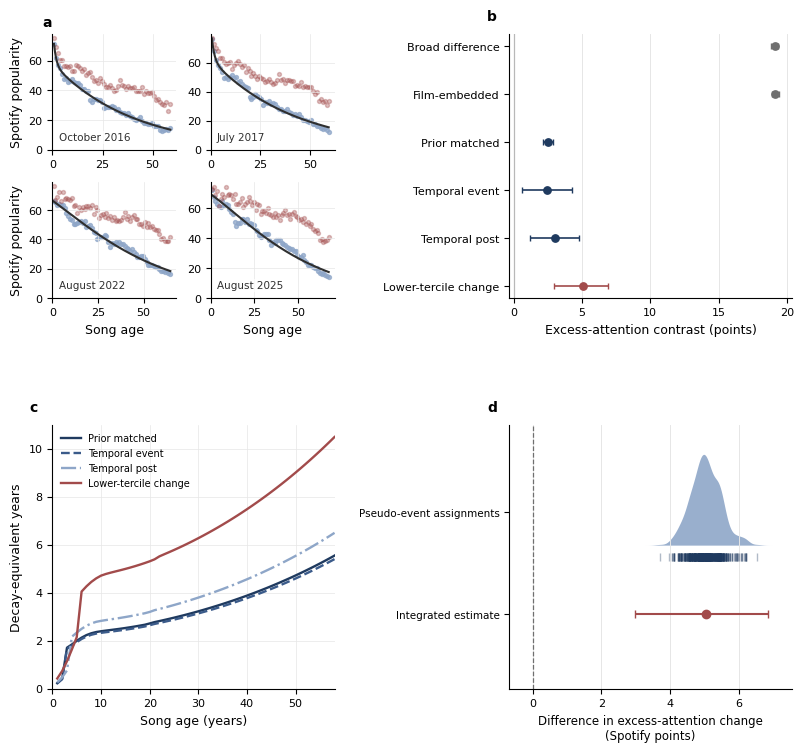

In [22]:
age_means = R("memorydecay_age_means.csv")
fits_table = R("memorydecay_fits.csv").set_index("snapshot")
panel_ex = pd.read_csv(paths.OUT_DATA / "spotify_song_snapshot_excess_attention.csv", low_memory=False)
from cdr.memorydecay import canonical_curve

def plot_fig2_memory(fig, outer):
    film_means = (panel_ex[panel_ex["film_linked"].eq(1)].assign(age_int=lambda d: np.floor(d["age"]).astype(int))
                  .groupby(["snapshot", "age_int"]).agg(age=("age", "mean"), attention=("attention", "mean")).reset_index())
    sub = outer.subgridspec(2, 2, hspace=0.28, wspace=0.28)
    axes = []
    for i, (snap, _, _, label) in enumerate(SNAPSHOTS):
        ax = fig.add_subplot(sub[i // 2, i % 2]); axes.append(ax)
        g0 = age_means[age_means["snapshot"].eq(snap)]
        g1 = film_means[film_means["snapshot"].eq(snap)]
        ax.scatter(g0["age"], g0["attention"], s=8, color=LIGHT_BLUE, alpha=0.75)
        ax.scatter(g1["age"], g1["attention"], s=8, color=ACCENT, alpha=0.35)
        p = fits_table.loc[label]
        xs = np.linspace(max(0.1, g0["age"].min()), g0["age"].max(), 240)
        ax.plot(xs, canonical_curve(xs, p["N"], p["p"], p["r"], p["q"]), color=CHARCOAL, lw=1.5)
        ax.text(0.05, 0.08, label, transform=ax.transAxes, fontsize=7.5, color=CHARCOAL,
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "pad": 0.8})
        ax.grid(color=GRID, lw=0.5); ax.set_xlim(left=0); ax.set_ylim(bottom=0)
        if i // 2 == 1: ax.set_xlabel("Song age")
        if i % 2 == 0: ax.set_ylabel("Spotify popularity")
    panel_label(axes[0], "a")

def plot_fig2_layers(ax):
    rows = [
        ("Broad difference", pooled["estimate"], pooled["conf_low"], pooled["conf_high"], GRAY),
        ("Film-embedded", embedded["estimate"], embedded["conf_low"], embedded["conf_high"], GRAY),
        ("Prior matched", mrow["estimate"], mx_primary["ci_low"], mx_primary["ci_high"], DARK_BLUE),
        ("Temporal event", ev["estimate"], ev["conf_low"], ev["conf_high"], DARK_BLUE),
        ("Temporal post", po["estimate"], po["conf_low"], po["conf_high"], DARK_BLUE),
        ("Lower-tercile change", dorm["dormant_excess_point_estimate"], dorm["dormant_excess_integrated_ci_low"], dorm["dormant_excess_integrated_ci_high"], ACCENT),
    ]
    y = np.arange(len(rows))
    for i, (label, e, lo, hi, color) in enumerate(rows):
        errorbarh(ax, e, lo, hi, [y[i]], color=color, size=28)
    ax.axvline(0, color=LIGHT_GRAY, lw=0.9)
    ax.set_yticks(y); ax.set_yticklabels([r[0] for r in rows]); ax.invert_yaxis()
    ax.set_xlabel("Excess-attention contrast (points)"); ax.grid(axis="x", color=GRID, lw=0.7)

def plot_fig2_decay(ax):
    grid = R("decay_equivalent_age_grid.csv")
    styles = {
        "Matched residual": (DARK_BLUE, "-"),
        "Temporal event": (BLUE, "--"),
        "Temporal post": (LIGHT_BLUE, "-."),
        "Dormant integrated": (ACCENT, "-"),
    }
    for layer, (color, ls) in styles.items():
        g = grid[grid["evidence_layer"].eq(layer)]
        med = g.groupby("song_age")["decay_equivalent_years"].median()
        ax.plot(med.index, med.values, color=color, ls=ls, lw=1.7, label="Lower-tercile change" if layer == "Dormant integrated" else ("Prior matched" if layer == "Matched residual" else layer))
    ax.set_xlabel("Song age (years)")
    ax.set_ylabel("Decay-equivalent years")
    ax.legend(frameon=False, fontsize=7, loc="upper left")
    ax.grid(color=GRID, lw=0.5)
    ax.set_xlim(0, grid["song_age"].max())
    ax.set_ylim(bottom=0)

def plot_fig2_dormant(ax):
    from scipy.stats import gaussian_kde
    est = R("dormant_assignment_distribution.csv")["excess_attention_estimate"].to_numpy()
    xs = np.linspace(min(est.min(), 0) - 0.3, max(est.max(), dorm["dormant_excess_integrated_ci_high"]) + 0.3, 300)
    dens = gaussian_kde(est)(xs)
    base_y = 0.42
    ax.fill_between(xs, base_y, base_y + dens / dens.max() * 0.55, color=LIGHT_BLUE, alpha=0.9, lw=0)
    ax.plot(est, np.full(len(est), base_y - 0.07), "|", color=DARK_BLUE, ms=6, alpha=0.35)
    ax.errorbar([dorm["dormant_excess_point_estimate"]], [0.0],
                xerr=[[dorm["dormant_excess_point_estimate"] - dorm["dormant_excess_integrated_ci_low"]],
                      [dorm["dormant_excess_integrated_ci_high"] - dorm["dormant_excess_point_estimate"]]],
                fmt="o", color=ACCENT, ecolor=ACCENT, capsize=3, markersize=6)
    ax.axvline(0, color=GRAY, lw=0.9, ls="--")
    ax.set_yticks([base_y + 0.2, 0.0])
    ax.set_yticklabels(["Pseudo-event assignments", "Integrated estimate"], fontsize=7.5)
    ax.set_ylim(-0.45, 1.15)
    ax.set_xlabel("Difference in excess-attention change\n(Spotify points)", fontsize=8.5)
    ax.grid(axis="x", color=GRID, lw=0.7)

fig = plt.figure(figsize=(8.4, 7.4))
gs = GridSpec(2, 2, figure=fig, hspace=0.48, wspace=0.62, left=0.09, right=0.97, top=0.96, bottom=0.075)
plot_fig2_memory(fig, gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1]); ax_c = fig.add_subplot(gs[1, 0]); ax_d = fig.add_subplot(gs[1, 1])
plot_fig2_layers(ax_b); plot_fig2_decay(ax_c); plot_fig2_dormant(ax_d)
panel_label(ax_b, "b"); panel_label(ax_c, "c"); panel_label(ax_d, "d")
show_and_save_figure(fig, paths.OUT_FIG_MAIN / "figure2_expected_memory_excess_dormant.pdf")

In [23]:
# S: MemoryDecay support -- C7
sup_md = R("memorydecay_support.csv")
tex.write_table(paths.OUT_TABLES_SI / "table_si_memorydecay_support.tex",
    "Never-film baseline support for the snapshot-specific MemoryDecay fits.", "tab:si-memorydecay-support",
    ["Snapshot", r"\makecell[b]{Never-film\\ song-snapshots}", r"\makecell[b]{Positive\\ age cells}", r"\makecell[b]{Age\\ range}", r"\makecell[b]{Median\\ cell support}", r"\makecell[b]{Min\\ cell support}"],
    [[r["snapshot"], fmt_int(r["never_film_song_snapshots"]), fmt_int(r["positive_age_cells"]), f"{int(r['min_age_cell'])}--{int(r['max_age_cell'])}", fmt_num(r["median_cell_support"], 0), fmt_int(r["min_cell_support"])] for _, r in sup_md.iterrows()],
    note="Each curve summarizes a cross-sectional age-attention relationship within one snapshot. Songs are grouped by integer age within each snapshot, and the canonical curve is fitted to the mean Spotify popularity of each positive age cell with early-age weights $1/(t+10^{-3})$ capped at their 99th percentile.", escape_cells=False)

# S: MemoryDecay fitted parameters + model comparison -- C7, C8
comp = R("memorydecay_model_comparison.csv")
comp_wide = comp.pivot(index="snapshot", columns="model", values="rmse_log")
ft = R("memorydecay_fits.csv").set_index("snapshot")
rows = []
for snap in ft.index:
    r = ft.loc[snap]
    rows.append([snap, fmt_num(r["N"]), fmt_num(r["p"], 4), fmt_num(r["r"], 4), fmt_num(r["q"], 4),
                 "yes" if r["single_exponential_limit_flag"] else "no",
                 fmt_num(comp_wide.loc[snap, "canonical_biexponential_log"], 4),
                 fmt_num(comp_wide.loc[snap, "exponential_log"], 4),
                 fmt_num(comp_wide.loc[snap, "lognormal_log"], 4)])
tex.write_table(paths.OUT_TABLES_SI / "table_si_memorydecay_fits.tex",
    "Snapshot-specific canonical MemoryDecay parameters and model comparison.", "tab:si-memorydecay-fits",
    ["Snapshot", "$N$", "$p$", "$r$", "$q$", r"\makecell[b]{Near-coincident\\ rates}", r"\makecell[b]{RMSE$_{\log}$\\ canonical}", r"\makecell[b]{RMSE$_{\log}$\\ exponential}", r"\makecell[b]{RMSE$_{\log}$\\ log-normal}"],
    rows,
    note="Canonical fits use the log-response objective, the MemoryDecay starting grid, and early-age weighting on never-film age means. The near-coincident-rates flag identifies fits with $p+r-q<0.005$; decay-equivalent diagnostics include these curves. Exponential and log-normal comparison models are fitted to the same age means with the same weights; the log-normal comparison is the only model using log(age).",
    size=r"\footnotesize", stretch=1.05, escape_cells=False)

# S: decay-equivalent audit -- C10
dd = decay.copy()
rows = [[r["evidence_layer"].replace("Baseline-attention", "Prior-attention"), fmt_num(r["delta_excess_points"]), fmt_int(r["n_observations"]), fmt_num(r["median_years"]), f"[{r['iqr_low']:.2f}, {r['iqr_high']:.2f}]", fmt_num(100 * r["share_nonestimable"], 2) + "\\%"] for _, r in dd.iterrows()]
rows.append(["Lower pre-film excess-attention contrast (integrated)", fmt_num(dorm["dormant_excess_point_estimate"]), fmt_int(dorm["n_matched_pairs_per_assignment"]), fmt_num(dorm["dormant_decay_equivalent_years"]), fmt_ci(dorm["dormant_decay_integrated_ci_low"], dorm["dormant_decay_integrated_ci_high"]), fmt_num(100 * dorm["inversion_failure_rate"], 2) + "\\%"])
tex.write_table(paths.OUT_TABLES_SI / "table_si_decay_equivalent_audit.tex",
    "Decay-equivalent-years support and inversion diagnostics.", "tab:si-decay-equivalent-audit",
    ["Evidence layer", r"\makecell[b]{$\Delta$\\ (excess\\ points)}", "N", r"\makecell[b]{Median\\ years}", r"\makecell[b]{IQR /\\ 95\% CI}", r"\makecell[b]{Non-\\estimable}"],
    rows,
    note="For each contrast $\\Delta$ and song age $t$, the translation solves $S(t^*) = S(t) + \\Delta$ on the fitted snapshot-specific curve and reports $t - t^*$ over the relevant empirical age distribution. Non-estimable cases occur when the shifted target exceeds the fitted young-age maximum. The lower-tercile excess-attention row reports the integrated nested-bootstrap median and 95\\% CI (bootstrap-specific refitted curves) with the bootstrap-wide inversion failure rate.",
    col_spec=r">{\raggedright\arraybackslash}p{0.30\linewidth}>{\centering\arraybackslash}p{0.078\linewidth}>{\centering\arraybackslash}p{0.065\linewidth}>{\centering\arraybackslash}p{0.068\linewidth}>{\centering\arraybackslash}p{0.12\linewidth}>{\centering\arraybackslash}p{0.082\linewidth}",
    size=r"\footnotesize", stretch=1.05, escape_cells=False)

**Never-film baseline support for the snapshot-specific MemoryDecay fits.** (`tab:si-memorydecay-support`)

,Snapshot,Never-film song-snapshots,Positive age cells,Age range,Median cell support,Min cell support
0,October 2016,"13,522",59,0--58,220,116
1,July 2017,"14,056",60,0--59,215,139
2,August 2022,"17,732",65,0--64,249,111
3,August 2025,"21,528",68,0--67,278,167


**Snapshot-specific canonical MemoryDecay parameters and model comparison.** (`tab:si-memorydecay-fits`)

,Snapshot,N,p,r,q,Near-coincident rates,RMSE_ canonical,RMSE_ exponential,RMSE_ log-normal
0,October 2016,85.20,0.2743,0.5354,0.0249,no,0.0515,0.0664,0.1259
1,July 2017,84.88,0.2123,0.5232,0.0235,no,0.0659,0.0731,0.1517
2,August 2022,66.38,0.0136,0.0185,0.0321,yes,0.0593,0.0770,0.1441
3,August 2025,69.40,0.0119,0.0221,0.0340,yes,0.0868,0.1133,0.1954


**Decay-equivalent-years support and inversion diagnostics.** (`tab:si-decay-equivalent-audit`)

,Evidence layer,(excess points),N,Median years,IQR / 95% CI,Non- estimable
0,Prior-attention matched excess premium,2.52,"12,095",3.78,"[3.01, 4.64]",0.02%
1,Strict temporal event contrast,2.45,93,3.41,"[2.20, 4.94]",0.00%
2,Strict temporal post contrast,2.98,93,4.11,"[2.66, 5.94]",0.00%
3,Lower pre-film excess-attention contrast (inte...,5.04,119,6.88,"[3.89, 10.22]",0.01%


In [24]:
# S: long-format matching balance (song designs + strict temporal + dormant reduced-form) -- C13
bal_song = R("song_matching_balance_long.csv")
DORMANT_DESIGN_SHORT = {
    "Low baseline Spotify attention, bottom quartile": "Low baseline (Q1)",
    "Low baseline Spotify attention, bottom tercile": "Low baseline (T1)",
    "Reduced-form below-expected residual, bottom tercile": "Regression residual (T1)",
    "Historically successful but low baseline attention": "Hist. successful, low",
    "Older low-attention songs": "Older, low attention",
}
BAL_GROUP = [("", 1), ("", 1), ("", 1), ("", 1), ("Before matching", 3), ("After matching", 3)]
BAL_HEADER = ["Family", "Design", "Snapshot", "Covariate", "T mean", "C mean", "SMD", "T mean", "C mean", "SMD"]
bal_rows = []
for _, r in bal_song.iterrows():
    bal_rows.append(["song", "Hist." if r["design"].startswith("historical") else "Prior", SNAP_SHORT.get(r["snapshot"], r["snapshot"]), COV_LABEL.get(r["covariate"], r["covariate"]),
                     fmt_num(r["treated_mean_before"]), fmt_num(r["control_mean_before"]), fmt_num(r["smd_before"], 3),
                     fmt_num(r["treated_mean_after"]), fmt_num(r["control_mean_after"]), fmt_num(r["smd_after"], 3)])
strict_bal = R("strict_temporal_balance.csv")
for _, r in strict_bal[strict_bal["caliper"].eq(0)].iterrows():
    for cov, smd_col in [("Baseline Spotify attention (exact)", "baseline_smd"), ("Chart debut year", "chart_year_smd"), ("Billboard weeks", "weeks_smd"), ("Peak chart position", "peak_smd")]:
        bal_rows.append(["strict temporal", "Exact baseline", str(int(r["cohort"])), cov, "--", "--", "--", "--", "--", fmt_num(r[smd_col], 3)])
red_bal = R("dormant_reduced_form_balance.csv")
for _, r in red_bal.iterrows():
    bal_rows.append(["Baseline-attention placebo", DORMANT_DESIGN_SHORT.get(r["definition"], r["definition"]), "pooled", COV_LABEL.get(r["covariate"], r["covariate"]), "--", "--", "--", fmt_num(r["treated_mean"]), fmt_num(r["control_mean"]), fmt_num(r["smd_after"], 3)])
check(len(bal_rows) == len(bal_song) + 4 * len(strict_bal[strict_bal["caliper"].eq(0)]) + len(red_bal),
      "song balance table retains one row per balance record across all three families")
tex.write_longtable(paths.OUT_TABLES_SI / "table_si_matching_balance.tex",
    "Covariate balance across song-level, strict-temporal, and prior-attention matched designs.", "tab:si-matching-balance",
    BAL_HEADER, bal_rows,
    note="Hist.\\ = historical matching; Prior = prior-attention matching. Before columns compare all treated with all available controls before matching; after columns compare matched samples. Strict temporal rows report post-matching SMDs for the exact-baseline design by cohort (baseline attention is exactly balanced by construction); pre-matching means are not defined for the cohort-eligibility pools. Baseline-attention placebo rows report matched means and SMDs for the single-assignment reduced-form designs.",
    col_spec=r">{\raggedright\arraybackslash}p{0.08\linewidth}>{\raggedright\arraybackslash}p{0.12\linewidth}>{\raggedright\arraybackslash}p{0.08\linewidth}>{\raggedright\arraybackslash}p{0.17\linewidth}" + r">{\centering\arraybackslash}p{0.068\linewidth}" * 6,
    size=r"\footnotesize", group_header=BAL_GROUP, stretch=1.05)

PASS: song balance table retains one row per balance record across all three families


**Covariate balance across song-level, strict-temporal, and prior-attention matched designs.** (`tab:si-matching-balance`)

,Family,Design,Snapshot,Covariate,T mean,C mean,SMD,T mean,C mean,SMD
0,song,Hist.,2016,Chart debut year,1981.64,1986.63,-0.295,1981.64,1981.84,-0.013
1,song,Hist.,2016,Song age,35.16,30.17,0.295,35.16,34.96,0.013
2,song,Hist.,2016,Billboard weeks,15.80,11.62,0.497,15.80,15.52,0.031
3,song,Hist.,2016,Peak chart position,26.44,46.16,-0.692,26.44,26.65,-0.008
4,song,Hist.,2016,"Artist catalog size, excluding focal song",14.70,14.32,0.019,14.70,14.59,0.007
...,...,...,...,...,...,...,...,...,...,...
109,Baseline-attention placebo,"Older, low attention",pooled,Billboard weeks,--,--,--,9.66,9.62,0.010
110,Baseline-attention placebo,"Older, low attention",pooled,Peak chart position,--,--,--,40.33,39.79,0.019
111,Baseline-attention placebo,"Older, low attention",pooled,"Artist catalog size, excluding focal song",--,--,--,13.19,12.94,0.017
112,Baseline-attention placebo,"Older, low attention",pooled,"Artist total Billboard weeks, excluding focal ...",--,--,--,123.59,118.40,0.033


In [25]:
# S: matched-excess replacement-aware inference -- C14 (pooled matched-excess estimand)
rows = []
for _, r in mx_inf.iterrows():
    rows.append([r["method"], fmt_num(r["estimate"]), fmt_num(r["se"], 3), fmt_ci(r["ci_low"], r["ci_high"]),
                 fmt_int(r["n_pairs"]), fmt_int(r["n_treated_songs"]), fmt_int(r["n_control_songs"]),
                 "primary" if r["primary"] == "yes" else ""])
tex.write_table(paths.OUT_TABLES_SI / "table_si_matched_excess_inference.tex",
    "Replacement-aware inference for the pooled prior-attention matched-excess premium.", "tab:si-matched-excess-inference",
    ["Method", "Estimate", "SE", "95\% CI", "Pairs", r"\makecell[b]{Treated\\ songs}", r"\makecell[b]{Control\\ songs}", "Role"],
    rows,
    note="All methods evaluate the identical estimand on the identical 12{,}095-pair set with fixed pair-level excess differences; only the uncertainty calculation varies. The two-way pigeonhole bootstrap independently resamples treated song records and reused control song records and reweights pairs by the product of their cluster draw counts; it is primary because the pooled comparison both reuses control songs and repeats Billboard song identities across snapshots. Percentile intervals use 2{,}000 replications.",
    col_spec=r">{\raggedright\arraybackslash}p{0.26\linewidth}>{\centering\arraybackslash}p{0.082\linewidth}>{\centering\arraybackslash}p{0.05\linewidth}>{\centering\arraybackslash}p{0.09\linewidth}>{\centering\arraybackslash}p{0.065\linewidth}>{\centering\arraybackslash}p{0.072\linewidth}>{\centering\arraybackslash}p{0.072\linewidth}>{\raggedright\arraybackslash}p{0.09\linewidth}",
    size=r"\footnotesize", stretch=1.05, tabcolsep="3pt", escape_cells=False)

# S: dormant reduced-form definitions -- C15
red = R("dormant_reduced_form_placebo.csv")
rows = []
for _, r in red.iterrows():
    rows.append([("Baseline-popularity regression residual, bottom tercile" if r["definition"] == "Reduced-form below-expected residual, bottom tercile" else r["definition"]), fmt_int(r["n_dormant_treated"]), fmt_int(r["n_matched_pairs"]),
                 fmt_num(r["treated_change_mean"]), fmt_num(r["matched_control_change_mean"]),
                 fmt_num(r["placebo_adjusted_did"]), fmt_ci(r["boot_ci_low"], r["boot_ci_high"]), fmt_p(r["permutation_p_value"]),
                 fmt_num(r["did_no_replacement"]), fmt_num(r["max_abs_smd_after"], 3)])
tex.write_table(paths.OUT_TABLES_SI / "table_si_dormant_definitions.tex",
    "Baseline-attention definitions: support and single-assignment placebo-adjusted changes.", "tab:si-dormant-definitions",
    ["Definition", r"\makecell[b]{Selected\\ treated}", "Pairs", r"\makecell[b]{Treated\\ change}", r"\makecell[b]{Matched\\ control\\ change}", r"\makecell[b]{Placebo-\\ adjusted}", r"\makecell[b]{Bootstrap\\ 95\% CI}", r"\makecell[b]{Perm.\\ $p$}", r"\makecell[b]{No-\\replacement}", r"\makecell[b]{Max\\ $|$SMD$|$}"],
    rows,
    note="Four definitions use raw baseline Spotify popularity; the fifth uses the bottom tercile of residuals from a regression of baseline popularity on age, age squared, Billboard weeks, and peak position. Treated-derived thresholds are applied to both treated songs and pseudo-event never-film controls; one seeded pseudo-event assignment (single-assignment robustness, not the primary integrated design). The historically-successful low-attention definition has low support and is exploratory. Bootstrap intervals resample matched treated songs (1{,}000 draws); permutation $p$-values shuffle film-linked labels within the pooled set selected by each definition (2{,}000 draws).",
    col_spec=r">{\raggedright\arraybackslash}p{0.13\linewidth}>{\centering\arraybackslash}p{0.088\linewidth}>{\centering\arraybackslash}p{0.055\linewidth}>{\centering\arraybackslash}p{0.072\linewidth}>{\centering\arraybackslash}p{0.075\linewidth}>{\centering\arraybackslash}p{0.078\linewidth}>{\centering\arraybackslash}p{0.108\linewidth}>{\centering\arraybackslash}p{0.068\linewidth}>{\centering\arraybackslash}p{0.108\linewidth}>{\centering\arraybackslash}p{0.065\linewidth}",
    size=r"\footnotesize", stretch=1.05, tabcolsep="2.5pt", escape_cells=False)

# S: dormant integrated inference -- C14/C16 primary
sup_d = R("dormant_definition_support.csv")
labels = {
    "n_pseudo_event_assignments": "Pseudo-event assignments", "n_positive_assignments": "Assignments with positive contrast",
    "assignment_mean": "Assignment mean (integrated point estimate)", "assignment_median": "Assignment median",
    "assignment_sd": "Assignment SD", "assignment_interval_low": "Assignment interval, 2.5th pct",
    "assignment_interval_high": "Assignment interval, 97.5th pct",
    "dormant_excess_integrated_ci_low": "Integrated bootstrap 95\\% CI, low", "dormant_excess_integrated_ci_high": "Integrated bootstrap 95\\% CI, high",
    "valid_bootstrap_replications": "Valid nested-bootstrap replications",
    "treated_exit_probability": "Treated above-threshold probability", "control_exit_probability": "Matched-control above-threshold probability",
    "exit_difference_pp": "Above-threshold probability difference (pp)", "exit_integrated_ci_low": "Above-threshold integrated 95\\% CI, low (pp)", "exit_integrated_ci_high": "Above-threshold integrated 95\\% CI, high (pp)",
    "dormant_decay_equivalent_years": "Decay-equivalent years (median)", "dormant_decay_integrated_ci_low": "Decay-equivalent 95\\% CI, low", "dormant_decay_integrated_ci_high": "Decay-equivalent 95\\% CI, high",
    "inversion_failure_rate": "Inversion failure rate", "median_p95_control_reuse": "Median 95th-pct control reuse", "max_control_reuse": "Maximum control reuse",
    "n_matched_pairs_per_assignment": "Matched lower-tercile treated songs per assignment",
}
rows = [[lab, fmt_num(dorm[key], 3)] for key, lab in labels.items()]
support_rows = [[("lower-tercile pre-film excess-attention treated songs" if r["quantity"] == "dormant treated songs (bottom tercile)" else r["quantity"]), fmt_num(r["n"], 3) if isinstance(r["n"], float) else fmt_int(r["n"])] for _, r in sup_d.iterrows()]
tex.write_table(paths.OUT_TABLES_SI / "table_si_dormant_integrated_inference.tex",
    "Lower pre-film excess attention: support and Monte Carlo-integrated inference.", "tab:si-dormant-integrated-inference",
    ["Quantity", "Value"],
    support_rows + rows,
    note="Inference integrates 500 pseudo-event assignments and 250 nested-bootstrap replications with snapshot-specific MemoryDecay refitting, excess-attention reconstruction, pseudo-event reassignment, and rematching. The assignment interval is a design-stability distribution across pseudo-event assignments, not a confidence interval. The analytical support comprises 355 film-linked songs with pre-film and post-film snapshots; the 119 songs in the lower tercile of pre-film excess attention are matched in every pseudo-event assignment.",
    col_spec=r">{\raggedright\arraybackslash}p{0.52\linewidth}>{\centering\arraybackslash}p{0.18\linewidth}",
    size=r"\footnotesize", stretch=1.05, escape_cells=False)

**Replacement-aware inference for the pooled prior-attention matched-excess premium.** (`tab:si-matched-excess-inference`)

,Method,Estimate,SE,95% CI,Pairs,Treated songs,Control songs,Role
0,naive paired SE,2.52,0.088,"[2.35, 2.69]","12,095","4,534","4,764",
1,bootstrap over matched pairs,2.52,0.087,"[2.35, 2.69]","12,095","4,534","4,764",
2,block bootstrap over treated song records,2.52,0.089,"[2.34, 2.69]","12,095","4,534","4,764",
3,cluster bootstrap over reused control song rec...,2.52,0.128,"[2.27, 2.78]","12,095","4,534","4,764",
4,two-way pigeonhole bootstrap (treated x contro...,2.52,0.181,"[2.16, 2.87]","12,095","4,534","4,764",primary


**Baseline-attention definitions: support and single-assignment placebo-adjusted changes.** (`tab:si-dormant-definitions`)

,Definition,Selected treated,Pairs,Treated change,Matched control change,Placebo- adjusted,Bootstrap 95% CI,Perm. p,No- replacement,Max |SMD|
0,"Low baseline Spotify attention, bottom quartile",97,97,10.93,3.87,7.06,"[4.65, 9.43]",<0.001,6.71,0.029
1,"Low baseline Spotify attention, bottom tercile",124,124,10.16,4.60,5.57,"[3.56, 7.76]",<0.001,5.29,0.039
2,"Baseline-popularity regression residual, botto...",119,119,9.39,5.64,3.76,"[1.92, 5.76]",<0.001,3.60,0.062
3,Historically successful but low baseline atten...,19,19,10.84,6.11,4.74,"[-0.05, 9.74]",0.737,4.74,0.125
4,Older low-attention songs,94,94,10.93,3.20,7.72,"[5.33, 10.22]",<0.001,7.53,0.033


**Lower pre-film excess attention: support and Monte Carlo-integrated inference.** (`tab:si-dormant-integrated-inference`)

,Quantity,Value
0,film-linked songs with pre-film and post-film ...,355
1,bottom-tercile pre-film excess-attention thres...,9.876
2,lower-tercile pre-film excess-attention treate...,119
3,Pseudo-event assignments,500
4,Assignments with positive contrast,500
5,Assignment mean (integrated point estimate),5.044
6,Assignment median,5.029
7,Assignment SD,0.435
8,"Assignment interval, 2.5th pct",4.243
9,"Assignment interval, 97.5th pct",5.997
